In [91]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


# Importing Necessary Libraries

In [92]:
# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Data Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Model Training Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Reading the Data

In [93]:
df = pd.read_csv("/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv")

In [94]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [95]:
df.tail()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,2.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [96]:
df.size

5580960

In [97]:
df.shape

(253680, 22)

In [98]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [99]:
df.dtypes

Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

# Checking for Missing Values

In [101]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [102]:
df.isna().any()

Diabetes_012            False
HighBP                  False
HighChol                False
CholCheck               False
BMI                     False
Smoker                  False
Stroke                  False
HeartDiseaseorAttack    False
PhysActivity            False
Fruits                  False
Veggies                 False
HvyAlcoholConsump       False
AnyHealthcare           False
NoDocbcCost             False
GenHlth                 False
MentHlth                False
PhysHlth                False
DiffWalk                False
Sex                     False
Age                     False
Education               False
Income                  False
dtype: bool

# Checking for Class Imbalance

In [103]:
class_counts = df['Diabetes_012'].value_counts()
print("Class counts :", class_counts)
class_proportions = df['Diabetes_012'].value_counts(normalize=True) * 100
print("\nClass proportions :", class_proportions)

Class counts : Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

Class proportions : Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64


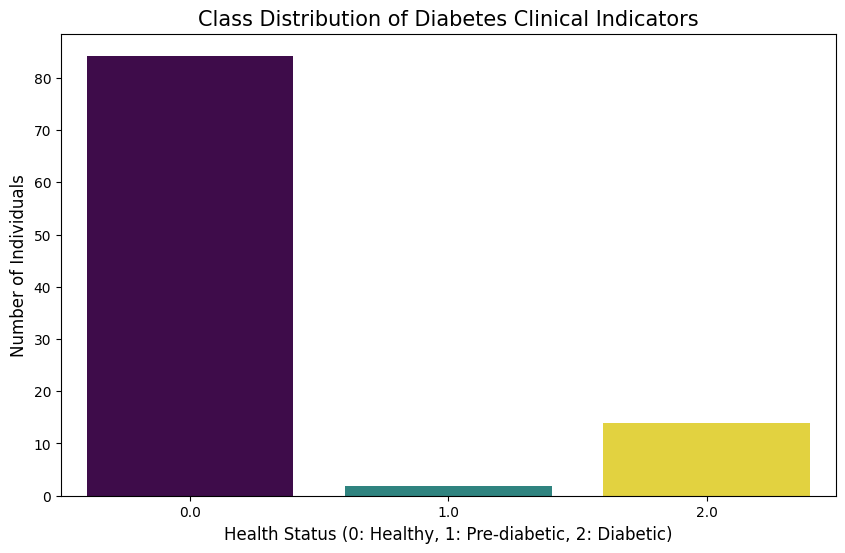

In [104]:
# Visualizing the Imbalance 
plt.figure(figsize=(10,6))
sns.barplot(x=class_counts.index, y=class_proportions.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Class Distribution of Diabetes Clinical Indicators', fontsize=15)
plt.xlabel('Health Status (0: Healthy, 1: Pre-diabetic, 2: Diabetic)', fontsize=12)
plt.ylabel('Number of Individuals', fontsize=12)
plt.show()

# Balancing the Classes

In [105]:
# Separating each classes
df_0 = df[df['Diabetes_012'] == 0]
df_1 = df[df['Diabetes_012'] == 1]
df_2 = df[df['Diabetes_012'] == 2]

In [106]:
len(df_0), len(df_1), len(df_2)

(213703, 4631, 35346)

In [107]:
# Undersampling df_0 to match df_2 :
n_sample = len(df_1)
under_df_0 = df_0.sample(n_sample, random_state=42)
under_df_2 = df_2.sample(n_sample, random_state=42)

# Combining
df_balanced = pd.concat([under_df_0, df_1, under_df_2], axis=0)
print("New balanced distribution :")
print(df_balanced['Diabetes_012'].value_counts())

New balanced distribution :
Diabetes_012
0.0    4631
1.0    4631
2.0    4631
Name: count, dtype: int64


# EDA 

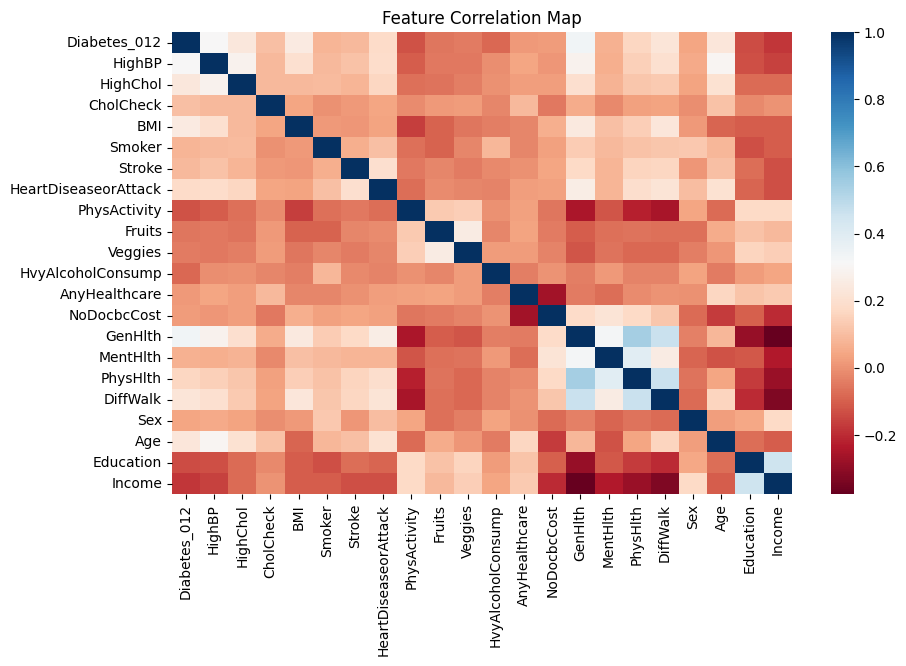

In [108]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df_balanced.corr(), annot=False, cmap='RdBu')
plt.title('Feature Correlation Map')
plt.show()

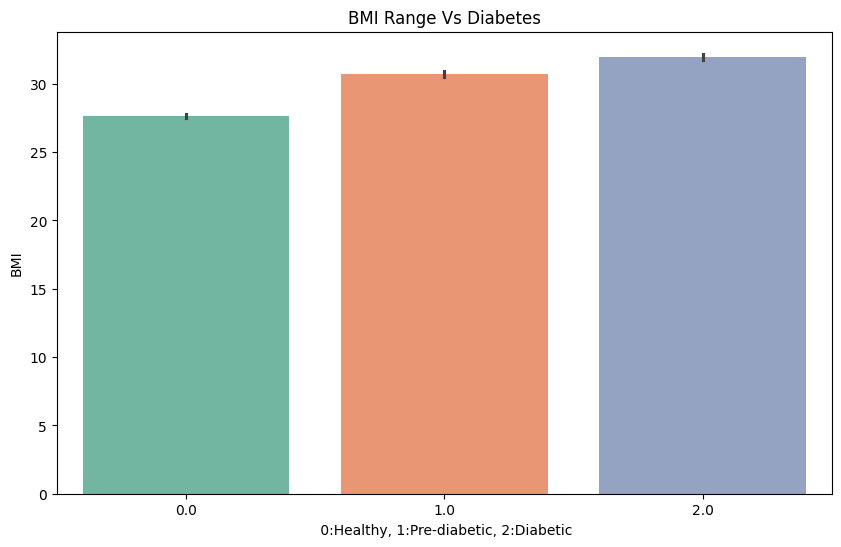

In [109]:
# BMI Range
plt.figure(figsize=(10,6))
sns.barplot(x='Diabetes_012', y='BMI', data=df_balanced, hue='Diabetes_012', legend=False, palette='Set2')
plt.title("BMI Range Vs Diabetes")
plt.xlabel(' 0:Healthy, 1:Pre-diabetic, 2:Diabetic')
plt.show()

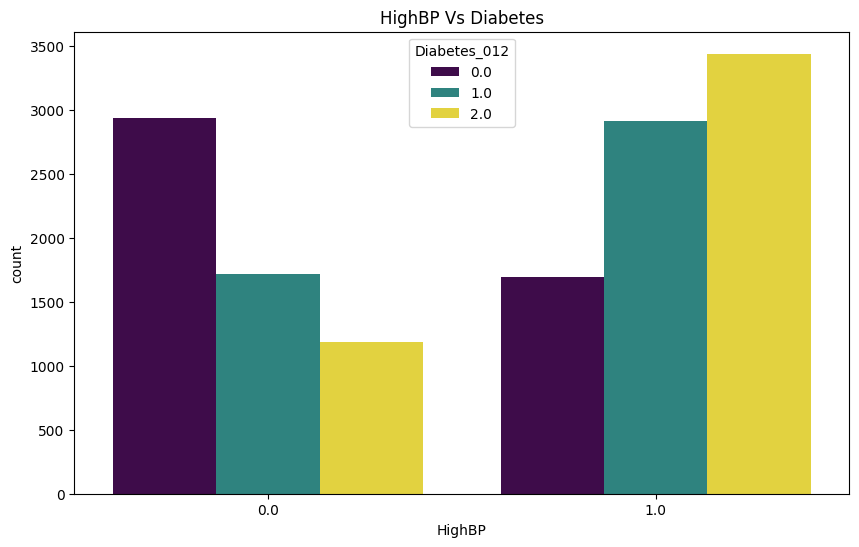

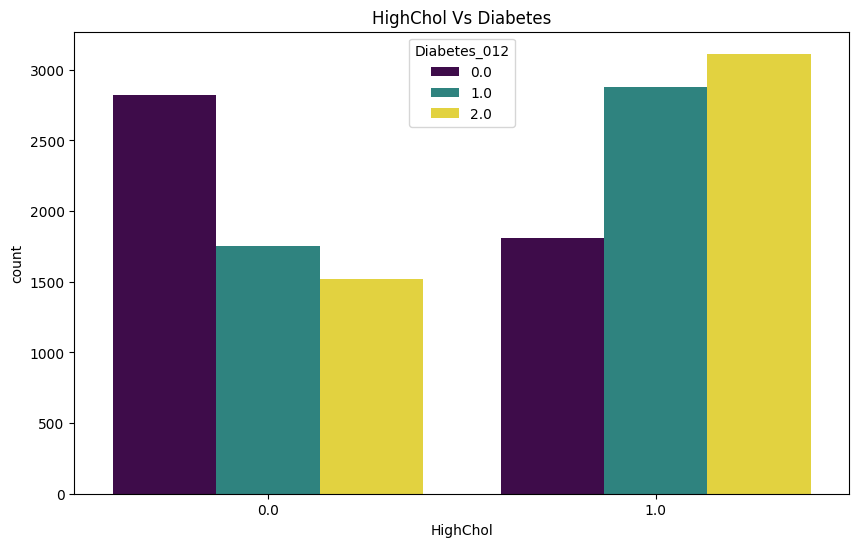

In [110]:
# HighBloodPressure & HighCholestrol

plt.figure(figsize=(10, 6))
sns.countplot(x='HighBP', data=df_balanced, hue='Diabetes_012', palette='viridis')
plt.title("HighBP Vs Diabetes")
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='HighChol', data=df_balanced, hue='Diabetes_012', palette='viridis')
plt.title("HighChol Vs Diabetes")
plt.show()

In [111]:
# Checking for the Outliers
print(df_balanced[['BMI', 'PhysHlth', 'MentHlth', 'Age']].describe())

                BMI      PhysHlth      MentHlth           Age
count  13893.000000  13893.000000  13893.000000  13893.000000
mean      30.115958      5.948391      3.908947      8.763550
std        7.102212     10.147984      8.261534      2.774834
min       13.000000      0.000000      0.000000      1.000000
25%       25.000000      0.000000      0.000000      7.000000
50%       29.000000      0.000000      0.000000      9.000000
75%       33.000000      7.000000      3.000000     11.000000
max       98.000000     30.000000     30.000000     13.000000


In [112]:
df_balanced['BMI'] = df_balanced['BMI'].clip(upper=60)
df_balanced['PhysHlth'] = df_balanced['PhysHlth'].clip(upper=30)
df_balanced['MentHlth'] = df_balanced['MentHlth'].clip(upper=30)

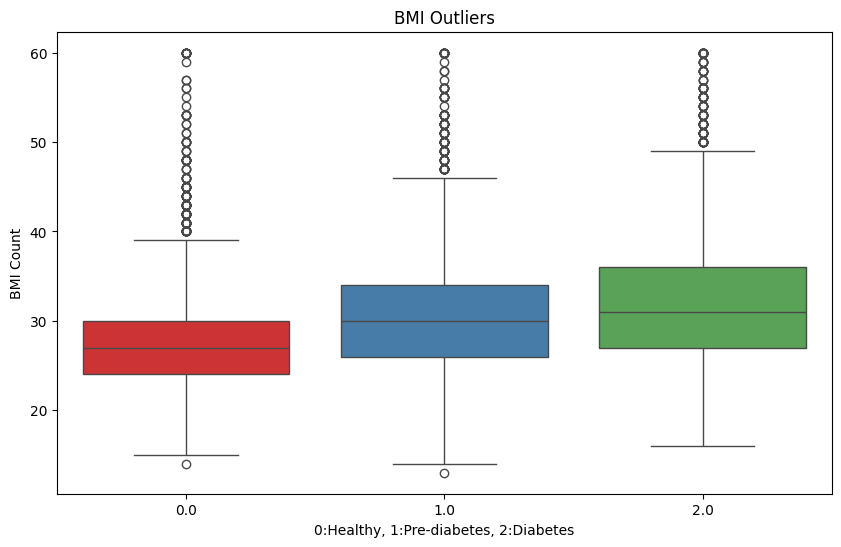

In [113]:
# Visualizing BMI Outliers
plt.figure(figsize=(10,6))
sns.boxplot(x='Diabetes_012', y='BMI', data=df_balanced, hue='Diabetes_012', legend=False, palette='Set1')
plt.title("BMI Outliers")
plt.xlabel( "0:Healthy, 1:Pre-diabetes, 2:Diabetes")
plt.ylabel("BMI Count")
plt.show()

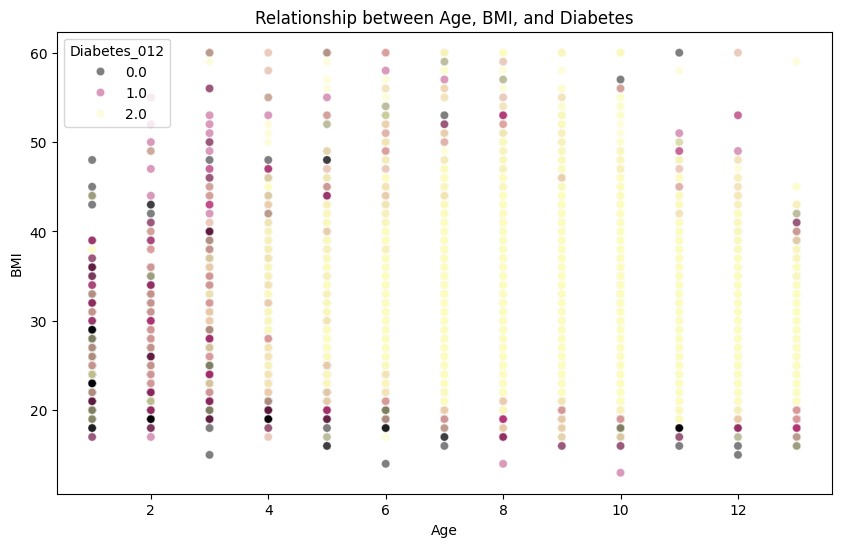

In [114]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='BMI', hue='Diabetes_012', data=df_balanced, alpha=0.5, palette='magma')
plt.title("Relationship between Age, BMI, and Diabetes")
plt.show()

# Model Training

In [115]:
# Defining Features(X) and Target(Y)
X = df_balanced.drop('Diabetes_012', axis=1)
Y = df_balanced['Diabetes_012']

In [116]:
# Splitting the data into training and testing sets
# 90% for training, 10% for testing

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42, stratify=Y)


In [117]:
# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Evaluation

In [118]:
# A function to train multiple models and to return evaluation metric

def evaluate_model(model, X_train_scaled, X_test_scaled, Y_train, Y_test):

    # Train the model
    model.fit(X_train_scaled, Y_train)

    # Make predictions on test data
    y_pred = model.predict(X_test_scaled)


    # Calculate evaluation metrics
    class_mat = print(classification_report(Y_test, y_pred))

    return class_mat

In [119]:
# Model 1 : LogisticRegression

lr = LogisticRegression(max_iter=400)
lr_class_mat = evaluate_model(lr,  X_train_scaled, X_test_scaled, Y_train, Y_test)


              precision    recall  f1-score   support

         0.0       0.59      0.69      0.64       463
         1.0       0.48      0.34      0.40       463
         2.0       0.53      0.59      0.56       464

    accuracy                           0.54      1390
   macro avg       0.53      0.54      0.53      1390
weighted avg       0.53      0.54      0.53      1390



In [120]:
# Model 2 : SVM

svc =  SVC(kernel="linear", C=1)
svc_class_mat = evaluate_model(svc,  X_train_scaled, X_test_scaled, Y_train, Y_test)


              precision    recall  f1-score   support

         0.0       0.60      0.66      0.63       463
         1.0       0.47      0.33      0.39       463
         2.0       0.53      0.64      0.58       464

    accuracy                           0.54      1390
   macro avg       0.53      0.54      0.53      1390
weighted avg       0.53      0.54      0.53      1390



In [121]:
# Model 3 : DecisionTreeClassifier

dtc = DecisionTreeClassifier(criterion="entropy")
dtc_class_mat = evaluate_model(dtc,  X_train_scaled, X_test_scaled, Y_train, Y_test)


              precision    recall  f1-score   support

         0.0       0.47      0.49      0.48       463
         1.0       0.36      0.36      0.36       463
         2.0       0.42      0.40      0.41       464

    accuracy                           0.42      1390
   macro avg       0.42      0.42      0.42      1390
weighted avg       0.42      0.42      0.42      1390



In [122]:
# Model 4 : RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100)
rfc_class_mat = evaluate_model(rfc,  X_train_scaled, X_test_scaled, Y_train, Y_test)


              precision    recall  f1-score   support

         0.0       0.59      0.61      0.60       463
         1.0       0.42      0.37      0.39       463
         2.0       0.51      0.56      0.54       464

    accuracy                           0.51      1390
   macro avg       0.51      0.51      0.51      1390
weighted avg       0.51      0.51      0.51      1390



In [123]:
# Model 5 : xgboost

xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, objective='multi:softprob')
xgb_class_mat = evaluate_model(xgb,  X_train_scaled, X_test_scaled, Y_train, Y_test)


              precision    recall  f1-score   support

         0.0       0.61      0.62      0.61       463
         1.0       0.44      0.35      0.39       463
         2.0       0.52      0.62      0.57       464

    accuracy                           0.53      1390
   macro avg       0.52      0.53      0.52      1390
weighted avg       0.52      0.53      0.52      1390



# Comparing Model Performance 

In [124]:
results = {
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.54, 0.54, 0.43, 0.52, 0.53], # Example numbers
    'Class_2 Recall': [0.59, 0.64, 0.41, 0.56, 0.62],
    'Macro F1': [0.53, 0.53, 0.43, 0.51, 0.52]
}

comparison_df = pd.DataFrame(results)
comparison_df.sort_values(by='Accuracy', ascending=False, inplace=True)
print(comparison_df)

                 Model  Accuracy  Class_2 Recall  Macro F1
0  Logistic Regression      0.54            0.59      0.53
1                  SVM      0.54            0.64      0.53
4              XGBoost      0.53            0.62      0.52
3        Random Forest      0.52            0.56      0.51
2        Decision Tree      0.43            0.41      0.43


# Most Influential Factors

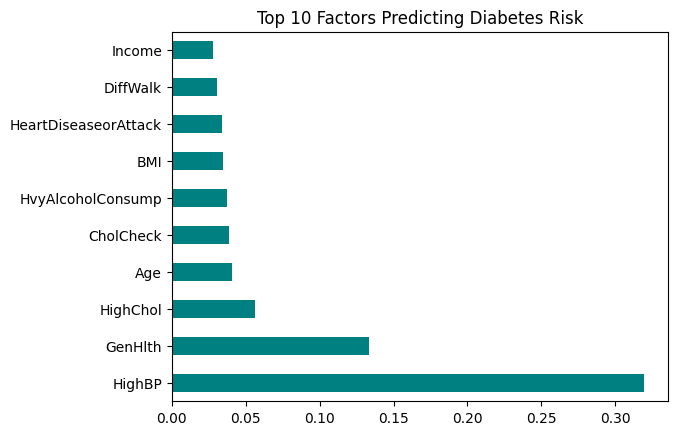

In [125]:
feature = xgb.feature_importances_
feat_importances = pd.Series(feature, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Factors Predicting Diabetes Risk")
plt.show()

# Saving The Winning Model (SVC)

In [126]:
import joblib

joblib.dump(svc, 'diabetes_svm_model.pkl') # saving the model
joblib.dump(scaler, 'data_scaler.pkl')# saving the scaler 

['data_scaler.pkl']